# Week 7 Assignment: ARIA v4.0 (The Accessible Auditor)



## 確認環境及套件 Environment Setup

Confirm the following packages are installed:`osmnx`, `networkx`, `geopandas`, `pandas`, `numpy`, `matplotlib`, `shapely`


In [1]:
# [S1] Environment Setup
import osmnx as ox
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# Check version
print(f"OSMnx: {ox.__version__}")
print(f"NetworkX: {nx.__version__}")
print(f"GeoPandas: {gpd.__version__}")

# Font configuration (If Chinese language support is needed)
rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'DejaVu Sans']  # fallback
rcParams['axes.unicode_minus'] = False


OSMnx: 2.0.7
NetworkX: 3.4.2
GeoPandas: 1.1.3


## 提取區域路網資料
透過 **OSMnx** 函式庫從 OpenStreetMap (OSM) 獲取指定區域的道路網絡，建立空間分析與衝擊評估的基礎模型。

**執行邏輯與參數設定**：
- **地理定位**：指定搜尋位置 `place_name` 為 "Hualien City, Taiwan"（花蓮市）。
- **空間範圍**：以中心座標為基準，設定搜尋半徑 `dist_meters = 5000` (5公里) 以涵蓋核心受災評估區。
- **路網類型**：設定參數 `network_type = 'drive'`，篩選出可供車輛行駛的道路，過濾掉行人步道以符合救援車輛通行模擬。
- **穩健性處理**：建立 `try-except` 錯誤捕捉機制，針對 Overpass API 連線逾時或地點辨識失敗提供排錯指引，確保自動化流程的穩定性。

In [29]:
from dotenv import load_dotenv

# 1. 載入 .env 檔案中的環境變數
load_dotenv()

# 2. 讀取變數
# 注意：從環境變數讀取的結果永遠是「字串」，如果需要數值運算必須轉換型別
network_dist = int(os.getenv("NETWORK_DIST", 5000))  # 5000 是預設值，預防檔案讀不到時出錯

print(f"成功載入搜尋半徑：{network_dist} 公尺")

成功載入搜尋半徑：5000 公尺


In [30]:
# [S2] Attempt Road Network Extraction
# If using place name, confirm the location exists (e.g., "Hualien City, Taiwan")

# place_name = "Hualien City, Taiwan"  # TODO: Change to your chosen location
place_name = "Hualien City, Taiwan"
network_type = 'drive'
dist_meters = network_dist   # Search radius (meters)

print(f"📍 Extracting {place_name} road network...")

try:
    # TODO: Use ox.graph_from_address() to extract road network
    G = ox.graph_from_address(place_name, dist=dist_meters, network_type=network_type)
    print(f"✅ Extraction successful: {G.number_of_nodes()} Node(s), {G.number_of_edges()} edge(s)")
except Exception as e:
    print(f"❌ Extraction failed: {e}")
    print("Possible causes:")
    print("  - Location name does not existor format error")
    print("  - Network connection issue (Overpass API Timeout)")
    print("  - Recommend waiting a few minutes and retry,oruse ox.settings.timeout = 300")


📍 Extracting Hualien City, Taiwan road network...
✅ Extraction successful: 3421 Node(s), 9815 edge(s)


## 座標投影與數值轉換 (Coordinate Projection)
將原始的地理座標系統 (WGS84) 轉換為台灣標準的平面投影座標系統 (TWD97 / TM2 121分帶)，這是進行精確距離與面積運算的核心步驟。

**執行邏輯與技術重點**：
- **座標系統轉換**：透過 `ox.project_graph` 函式將路網投影至 **EPSG:3826**。此舉將空間單位由「度」轉換為「公尺」，為後續行車時間與等時圈面積計算提供正確的物理單位基礎。
- **自動化簡化**：基於 OSMnx 2.0+ 規範，投影過程中會自動處理路網拓撲簡化，確保圖論模型結構精簡。
- **資料驗證**：投影完成後即時輸出節點（Nodes）與路段（Edges）總數，並檢查圖資的 CRS 屬性，確保模型已正確切換至目標投影系統。

In [3]:
# [S3] Project to Meter Coordinates
# Note: OSMnx >=2.0 automatically simplifies, no manual call needed simplify_graph()

# TODO: Project to EPSG:3826 (TWD97/TM2)
G_proj = ox.project_graph(G, to_crs='EPSG:3826')

print(f"Node count: {G_proj.number_of_nodes()}")
print(f"Number of edges: {G_proj.number_of_edges()}")
print(f"CRS: {G_proj.graph['crs']}")
print("✅ Projection complete")


Node count: 3421
Number of edges: 9815
CRS: EPSG:3826
✅ Projection complete


## 計算基礎通行時間 (Travel Time Calculation)
建立路網中每一路段（Edge）在常態情況下的基礎通行成本（行車時間），作為後續可及性分析與災害衝擊評估的基準值。

**執行邏輯與技術重點**：
- **建立道路權重基準**：定義 `speed_defaults` 字典，針對 OpenStreetMap 的道路等級（如高速公路、主幹道、巷弄等）給予對應的標準行車時速，確保模型符合現實交通情境。
- **穩健的速限提取機制**：設計 `get_speed_kph` 函式處理複雜的 OSM 原始屬性。該函式優先讀取 `maxspeed` 標籤，並具備錯誤處理能力，可自動解析清單格式（Lists）或無效字串；若無速限資訊，則根據道路類型自動補值。
- **物理量轉換與計算**：
    - **單位轉換**：將時速 (km/h) 轉換為公尺/秒 (m/s)，轉換公式為：$$v_{m/s} = \frac{v_{km/h}}{3.6}$$。
    - **通行成本計算**：利用路段長度（meters）除以行駛速度，計算出該路段的常態通行秒數，並存入新欄位 `travel_time_normal`。
- **資料驗證**：透過抽樣檢查（Sample Edge）輸出路段長度、速限與通行時間，確認計算邏輯之正確性與數值合理性。

In [4]:
# [S4] Calculate Travel Time
# Calculate base travel time for each edge (unit: seconds)

# Highway type speed reference table (consistent with Demo Cell [3])
speed_defaults = {
    'motorway': 110, 'motorway_link': 80,
    'trunk': 100, 'trunk_link': 60,
    'primary': 80, 'primary_link': 50,
    'secondary': 60, 'secondary_link': 40,
    'tertiary': 50, 'tertiary_link': 30,
    'residential': 40, 'living_street': 10,
    'unclassified': 30, 
}

def get_speed_kph(data):
    """From OSM edge data Get speed (km/h),and Demo Cell [3] Consistent."""
    maxspeed = data.get('maxspeed', None)
    if maxspeed:
        try:
            return float(maxspeed)
        except (ValueError, TypeError):
            if isinstance(maxspeed, list):
                try:
                    return float(maxspeed[0])
                except:
                    pass
    highway = data.get('highway', 'residential')
    if isinstance(highway, list):
        highway = highway[0]
    return speed_defaults.get(highway, 40)

# TODO: Traverse all edges,Calculate travel_time_normal
for u, v, k, data in G_proj.edges(data=True, keys=True):
    length = data['length']  # meters
    speed_kph = get_speed_kph(data)
    speed_ms = speed_kph / 3.6  # Convert to m/s
    data['travel_time_normal'] = length / speed_ms  # seconds
    data['speed_kph'] = speed_kph

# Check
sample_edge = list(G_proj.edges(data=True, keys=True))[0]
print(f"Sample edges: length={sample_edge[3]['length']:.1f}m, "
      f"speed={sample_edge[3]['speed_kph']:.1f}km/h, "
      f"travel_time={sample_edge[3]['travel_time_normal']:.1f}s")
print("✅ Travel time calculation complete")
list(G_proj.edges(data=True, keys=True))[4]


Sample edges: length=17.7m, speed=30.0km/h, travel_time=2.1s
✅ Travel time calculation complete


(883096208,
 883096381,
 0,
 {'osmid': 74751611,
  'highway': 'primary',
  'name': '光復路',
  'oneway': True,
  'reversed': False,
  'length': 157.0833619925083,
  'maxspeed': '70',
  'ref': '9',
  'geometry': <LINESTRING (311875.82 2657691.357, 311879.59 2657713.513, 311902.12 2657829...>,
  'travel_time_normal': 8.078572902471855,
  'speed_kph': 70.0})

## 儲存路網模型 (Save Road Network)
將處理完成且帶有計算屬性（如行車時間）的路網模型序列化並儲存，以利後續分析直接讀取，避免重複下載資料與重啟運算。

**執行邏輯與技術重點**：
- **資料持久化**：使用 `ox.save_graphml` 函式將投影後的路網物件 `G_proj` 儲存為 `.graphml` 格式。此格式可完整保留圖論結構（Topology）以及每一條邊（Edge）與節點（Node）的自訂屬性。
- **檔案路徑管理**：預設儲存於 `output/hualien_network.graphml`，確保專案目錄結構化，方便跨腳本（Script）調用。
- **開發效率優化**：透過檔案儲存，可大幅減少對 Overpass API 的存取次數，並確保分析過程中使用的圖資數據版本一致。

In [5]:
# Save Road Network as GraphML
# Save the road network as .graphml (avoid redundant downloads)

graphml_path = "../output/hualien_network.graphml"
ox.save_graphml(G_proj, graphml_path)
print("✅ Road network saved as GraphML")

✅ Road network saved as GraphML


In [6]:
# Can be read directly later (1 second to read vs 30 seconds to download)
G_proj = ox.load_graphml(graphml_path)
print(f"loadinputNode count: {G_proj.number_of_nodes()}")

loadinputNode count: 3421


In [7]:
list(G_proj.edges(data=True, keys=True))[4]

(883096208,
 883096381,
 0,
 {'osmid': 74751611,
  'highway': 'primary',
  'name': '光復路',
  'oneway': True,
  'reversed': False,
  'length': 157.0833619925083,
  'maxspeed': '70',
  'ref': '9',
  'geometry': <LINESTRING (311875.82 2657691.357, 311879.59 2657713.513, 311902.12 2657829...>,
  'travel_time_normal': '8.078572902471855',
  'speed_kph': 70.0})

## 計算路網介數中心性 (Betweenness Centrality)
利用圖論演算法識別路網中的核心樞紐與潛在瓶頸節點，評估各節點在區域交通流中的重要程度。

**執行邏輯與技術重點**：
- **演算法核心**：採用 `nx.betweenness_centrality` 計算介數中心性。此指標代表通過該節點的最短路徑數量佔總數的比例，數值越高表示該點越具有「交通扼守」的特性。
- **權重設定**：以路段長度 `length` 作為權重進行最短路徑搜尋。這能確保計算結果符合真實地理距離，反映物理空間上的交通必經之處。
- **瓶頸識別**：計算完成後，對所有節點的中心性數值進行降冪排序，並提取前 5 名（Top 5）節點。這些節點被定義為「瓶頸節點 (Bottleneck Nodes)」，在災害發生導致路網受損時，其失效將對區域交通可及性產生最大衝擊。
- **量化輸出**：輸出各瓶頸節點的 ID 與精確中心性數值，為後續的地形風險疊加與資源調度提供量化依據。

In [8]:
# [S5] Calculate Centrality
# Use NetworkX betweenness_centrality
# Use 'length' (road segment length) as weight

print("⏳ Calculating Betweenness Centrality...")

# TODO: Use nx.betweenness_centrality() Calculate
centrality = nx.betweenness_centrality(G_proj, weight='length')

print("✅ Calculation complete")

# TODO: Find Top 5 Node(s)
top_5_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 Bottleneck Node(s):")
for rank, (node_id, cent_val) in enumerate(top_5_nodes, 1):
    print(f"{rank}. Node(s) {node_id}: Centrality = {cent_val:.6f}")


⏳ Calculating Betweenness Centrality...
✅ Calculation complete

Top 5 Bottleneck Node(s):
1. Node(s) 649286213: Centrality = 0.140247
2. Node(s) 649286214: Centrality = 0.139444
3. Node(s) 1061487893: Centrality = 0.125307
4. Node(s) 929963021: Centrality = 0.123480
5. Node(s) 1074772659: Centrality = 0.115733


## 疊加地形風險分析
將路網分析產出的瓶頸節點轉化為空間向量資料，並預留與地理環境風險圖層進行疊加分析的介面，以量化交通核心樞紐在自然災害下的脆弱程度。

**執行邏輯與技術重點**：
- **資料格式向量化**：利用 `gpd.GeoDataFrame` 將前 5 名瓶頸節點清單轉換為地理空間格式。透過 `shapely.geometry.Point` 提取路網模型中的 X、Y 座標資訊，賦予節點明確的空間幾何意義。
- **座標系統一致性**：設定 `crs=G_proj.graph['crs']`，確保分析節點與原始路網圖資在相同的平面座標投影 (EPSG:3826) 下進行運算，避免空間位移誤差。
- **空間連接 (Spatial Join) 準備**：預留 `gpd.sjoin` 的擴充介面，旨在執行「點與面」的空間疊加分析。此步驟可將外部地形風險圖層（如 Week 4 的風險底圖）之屬性直接關聯至瓶頸節點。
- **風險評估潛力**：此階段能篩選出同時具備「高交通介數中心性」與「高環境風險」的節點。若節點位於高風險區且其交通扼守性極強，則會被標註為系統中最脆弱的「關鍵失效點」，作為防災預警與搶修機具預置的首要依據。

In [9]:
# [S6] Terrain Risk Overlay (Advanced Option)
# If you have Week 4 terrain risk data, overlay it with bottleneck nodes
# If W4 data is not available, you can skip this step without affecting subsequent analysis
from shapely.geometry import Point
top_5_gdf = gpd.GeoDataFrame(
    [{'node_id': nid, 'centrality': cv,
      'geometry': Point(G_proj.nodes[nid]['x'], G_proj.nodes[nid]['y'])}
     for nid, cv in top_5_nodes],
    crs=G_proj.graph['crs']
)
print(f"✅ Top 5 Node(s) GeoDataFrame Establishment complete")
print(top_5_gdf[['node_id', 'centrality']])


✅ Top 5 Node(s) GeoDataFrame Establishment complete
      node_id  centrality
0   649286213    0.140247
1   649286214    0.139444
2  1061487893    0.125307
3   929963021    0.123480
4  1074772659    0.115733


In [10]:
top_5_gdf

,node_id,centrality,geometry
0,649286213,0.140247,POINT (310477.989 2652340.782)
1,649286214,0.139444,POINT (310676.296 2652359.262)
2,1061487893,0.125307,POINT (309886.314 2652282.802)
3,929963021,0.123480,POINT (311855.313 2653280.967)
4,1074772659,0.115733,POINT (310566.728 2653495.755)


## 輸出瓶頸節點資料 (Data Export and Audit Preparation)
將分析產出的空間向量資料轉換為結構化純文字報表，以便進行後續的跨平台數據交換、稽核紀錄與報表呈現。

**執行邏輯與技術重點**：
- **座標數值解構**：透過 `.geometry.x` 與 `.geometry.y` 屬性，將 GeoDataFrame 中的空間幾何資訊提取為獨立的「經度」與「緯度」數值欄位。此步驟確保即使在不具備 GIS 軟體（如 QGIS）的環境下，決策者仍能直接讀取節點的精確空間座標。
- **格式降維與轉換**：利用 `pd.DataFrame` 搭配 `drop` 方法移除無法直接序列化存入 CSV 的 `geometry` 物件欄位。將「空間格式」轉換為「標準表格格式」，以符合一般資料庫與試算表軟體的讀取規範。
- **跨平台相容性優化**：匯出時指定 `encoding='utf-8-sig'`。此編碼方式會在檔案開頭加入位元組順序標記（BOM），能有效解決 Excel 在開啟 UTF-8 編碼之中文 CSV 檔案時產生的亂碼問題，確保分析結果在應變中心不同作業系統間的互操作性。

In [11]:
# 1. 提取座標數值到新欄位
top_5_gdf['經度'] = top_5_gdf.geometry.x
top_5_gdf['緯度'] = top_5_gdf.geometry.y

# 2. 轉換為一般 DataFrame (移除 geometry 欄位以便儲存為純文字 CSV)
df_export = pd.DataFrame(top_5_gdf.drop(columns='geometry'))

# 3. 輸出成 CSV
# 使用 utf-8-sig 可以確保 Excel 打開時中文字不會亂碼
df_export.to_csv('../output/top_5_bottlenecks.csv', index=False, encoding='utf-8-sig')

print("CSV 檔案已產生：output/top_5_bottlenecks.csv")

CSV 檔案已產生：output/top_5_bottlenecks.csv


### 將上述資料透過HW4的檔案計算求得各節點的地形風險資料(另外在ARIA_v2.ipynb檔案中執行)，並讀取結果("../outputs/nodes_terrain_risk_audit.json")

In [12]:
# 讀取 JSON 檔案
df_result = pd.read_json("../output/nodes_terrain_risk_audit.json")
# 查看前幾筆資料
print("資料讀取成功！")
display(df_result.head())
print("node_id=649286213的節點最脆弱，因為它的介數中心性最高，且位於高風險區域。")


資料讀取成功！


,node_id,centrality,longitude,latitude,經度,緯度,mean_elevation,std_elevation,max_slope,risk_level,river_distance_category
0,649286213,0.140247,310477.988981,2.652341e+06,310477.988981,2.652341e+06,14.265105,1.940977,11.909060,高風險,<500m
1,649286214,0.139444,310676.295536,2.652359e+06,310676.295536,2.652359e+06,12.836456,1.931765,5.644842,中風險,<1000m
2,1061487893,0.125307,309886.313535,2.652283e+06,309886.313535,2.652283e+06,18.492570,1.952160,11.909060,高風險,<500m
3,929963021,0.123480,311855.312634,2.653281e+06,311855.312634,2.653281e+06,8.196966,6.064966,25.365629,高風險,<500m
4,1074772659,0.115733,310566.727911,2.653496e+06,310566.727911,2.653496e+06,13.930797,2.207673,6.076158,低風險,>1000m


node_id=649286213的節點最脆弱，因為它的介數中心性最高，且位於高風險區域。


## 瓶頸節點與地形風險視覺化 (Visualization of Bottlenecks and Terrain Risk)
將路網分析計算出的前五大關鍵瓶頸節點，結合地形風險分級進行空間圖資整合，產出直觀的災害風險專題地圖。

**執行邏輯與技術重點**：
- **路網底圖分層處理**：利用 `ox.plot_graph` 繪製背景路網，並設定 `edge_color='lightgray'` 進行底圖淡化處理。透過調整圖層權重，使分析目標（節點）在複雜的城市路網中能被清晰辨識。
- **風險分級顏色映射**：建立 `risk_color_map` 字典，將抽象的風險等級轉化為視覺直覺的語意顏色。例如「紅色」代表「極高風險」、「橘色」代表「高風險」，符合防災決策圖資的標準色碼規範。
- **動態節點標註與排序**：
    - **屬性篩選**：確保繪製對象為介數中心性（Centrality）最高的前五名核心節點。
    - **精確繪製**：依據投影後的 X、Y 座標進行標記，並使用 `ax.annotate` 加入排名標籤（如 #1, #2），協助決策者快速識別影響力最大的交通弱點。
- **專業地圖要素整合**：
    - **圖層堆疊管理**：設定 `zorder` 參數，確保瓶頸節點與標註顯示於路網底圖的最上層，避免遮蔽。
    - **自訂圖例 (Legend)**：利用 `matplotlib.lines.Line2D` 手動構建圖例，清楚解釋顏色與風險等級的對應關係，使圖表具備獨立閱讀與跨領域溝通的價值。

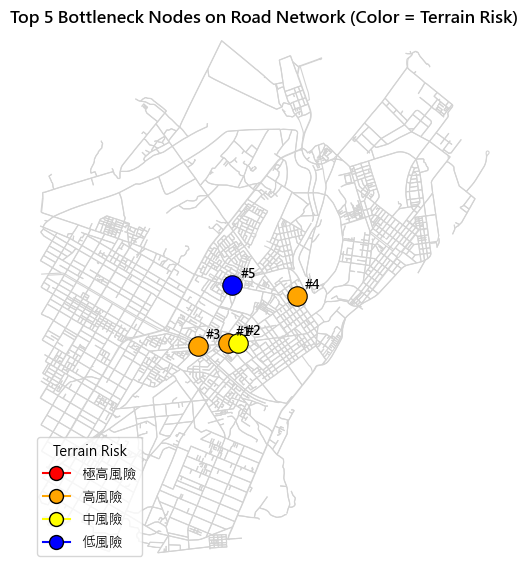

In [13]:
# [S7] Visualize Bottlenecks with Terrain Risk
# 目標：Top 5 節點顯示在路網上，顏色 = risk_level

fig, ax = plt.subplots(figsize=(12, 6))

# 1) 畫路網底圖（建議底圖淡一點，凸顯節點）
ox.plot_graph(
    G_proj, ax=ax,
    node_size=0,                 # 路網原始 node 不特別顯示
    edge_color='lightgray',
    edge_linewidth=0.8,
    show=False
)

# 2) 風險等級顏色映射（可自行調整）
risk_color_map = {
    '極高風險': 'red',  
    '高風險': 'orange',   
    '中風險': 'yellow',   
    '低風險': 'blue'    
}
default_color = '#3498db'  # 若遇到未知分類

# 3) 若 df_result 還沒保證是 Top5，先依 centrality 排序取前5
plot_df = df_result.sort_values('centrality', ascending=False).head(5).copy()

# 4) 繪製 Top5 節點（顏色依 terrain risk）
for rank, row in enumerate(plot_df.itertuples(index=False), 1):
    # 你的座標已是投影座標（EPSG:3826），可直接用經度/緯度欄位（其實是 x/y）
    x = getattr(row, '經度') if '經度' in plot_df.columns else row.longitude
    y = getattr(row, '緯度') if '緯度' in plot_df.columns else row.latitude

    risk = row.risk_level
    color = risk_color_map.get(risk, default_color)

    ax.plot(
        x, y,
        marker='o', markersize=14,
        color=color,
        markeredgecolor='black', markeredgewidth=0.8,
        zorder=10
    )
    ax.annotate(
        f'#{rank}',
        (x, y),
        fontsize=9, fontweight='bold',
        textcoords='offset points', xytext=(6, 6),
        zorder=11
    )

# 5) 自訂圖例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='red', label='極高風險', markerfacecolor=risk_color_map['極高風險'], markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='orange', label='高風險', markerfacecolor=risk_color_map['高風險'], markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='yellow', label='中風險', markerfacecolor=risk_color_map['中風險'], markeredgecolor='black', markersize=10),
    Line2D([0], [0], marker='o', color='blue', label='低風險', markerfacecolor=risk_color_map['低風險'], markeredgecolor='black', markersize=10),
]
ax.legend(handles=legend_elements, title='Terrain Risk', loc='lower left')

ax.set_title('Top 5 Bottleneck Nodes on Road Network (Color = Terrain Risk)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 定義降雨與交通擁塞映射函數 (Rainfall-to-Congestion Mapping)
實作將環境監測之降雨強度 (mm/hr) 轉化為路網分析阻抗指標（擁塞係數，Congestion Factor）的邏輯函數，作為計算動態權重的核心依據。

**執行邏輯與技術重點**：
- **多元演算法支持**：
    - **閾值模型 (Threshold)**：採用離散分級法，根據特定的雨量區間賦予相對應的擁塞係數（如 0.0、0.3、0.6、0.9），模擬降雨強度突破臨界值時交通能力的階梯式衰減。
    - **線性模型 (Linear)**：設定連續函數，使路網阻抗隨雨量等比例增加，並透過 `min(..., 0.95)` 機制防止係數超過物理極限。
    - **指數模型 (Exponential)**：利用 `np.exp` 模擬降雨影響的非線性特質，真實反映降雨在達到特定強度後，交通風險呈現指數級成長的特性。
- **類型穩定性確保**：函數強制將輸出結果轉換為 `float` 型別，避免在後續執行 Dijkstra 最短路徑演算法時，因數值型別不一致導致計算錯誤。
- **極端情境驗證**：針對測試清單進行模擬運算，特別包含「鳳凰颱風」實測之 130.5 mm/hr 極端值，確保函數在特大豪雨情境下仍能輸出正確的擁塞權重，為 ARIA 系統提供可靠的壓力測試基礎。

In [14]:
def rain_to_congestion(rainfall_mm, method='threshold'):
    """
    實作降雨量對應擁塞係數的映射函數
    """
    cf = 0.0 # 預設值
    
    if method == 'threshold':
        # 根據 Slide 12 的建議閾值
        if rainfall_mm < 1:
            cf = 0.0
        elif 1 <= rainfall_mm < 2:
            cf = 0.3
        elif 2 <= rainfall_mm < 3:
            cf = 0.6
        else: # >= 80mm
            cf = 0.9
            
    elif method == 'linear':
        # 線性映射：雨越大越慢，最高不超過 0.95
        cf = min(rainfall_mm / 100 * 0.9, 0.95)
        
    elif method == 'exponential':
        # 指數映射：模擬降雨初期影響較小，隨後急劇增加
        # 這裡需要用到 np.exp
        cf = 0.95 * (1 - np.exp(-rainfall_mm / 50))
    
    # 確保回傳值是 float 且不為 None
    return float(cf)


# Testing
rain_test = [0, 10, 40, 80, 100, 130.5]
for rain in rain_test:
    cf = rain_to_congestion(rain, method='threshold')
    print(f"Rainfall {rain:.1f} mm/hr → Congestion Factor {cf}")

Rainfall 0.0 mm/hr → Congestion Factor 0.0
Rainfall 10.0 mm/hr → Congestion Factor 0.9
Rainfall 40.0 mm/hr → Congestion Factor 0.9
Rainfall 80.0 mm/hr → Congestion Factor 0.9
Rainfall 100.0 mm/hr → Congestion Factor 0.9
Rainfall 130.5 mm/hr → Congestion Factor 0.9


## 載入空間雨量資料 (Rainfall Data Integration)
整合 Week 6 的 Kriging 空間插值結果，將離散的測站雨量轉化為連續的網格資料，為路網提供精確的降雨強度輸入。

**執行邏輯與技術重點**：
- **影像資料讀取**：利用 `rasterio` 函式庫讀取 GeoTIFF 格式的雨量圖層（`kriging_rainfall.tif`）。此格式能完整保存降雨空間分佈與對應的投影座標資訊，是計算動態阻抗的關鍵環境變數。
- **多源資料方案選擇**：
    - **方案 A (Raster)**：使用 Kriging 網格圖資，優點在於能提供全區域連續且平滑的雨量數值，適合精確計算每一條路段中點的降雨強度。
    - **方案 B (JSON)**：預留測站情境格式的讀取介面，提供在缺乏網格資料時，使用特定測站歷史降雨紀錄（如鳳凰颱風情境）的彈性。
- **空間對齊稽核 (CRS Sanity Check)**：在讀取後即時比對並輸出路網模型 (`G_proj`) 與降雨網格 (`rainfall_raster`) 的座標參考系統。此步驟為後續「空間取樣」的成功關鍵，確保路網的幾何座標能精確映射至雨量影像的像素索引（Pixel Index），避免因座標系統不一致導致的分析位移。

In [15]:
# Option A: Use W6 Kriging GeoTIFF
# kriging_path = "path/to/kriging_rainfall.tif"
# rainfall_raster = rasterio.open(kriging_path)

import rasterio
kriging_path = "../data/kriging_rainfall.tif"
rainfall_raster = rasterio.open(kriging_path)

print("✅ Rainfall data reading")
print(f"路網 CRS: {G_proj.graph['crs']}")
print(f"降雨網格 CRS: {rainfall_raster.crs}")


✅ Rainfall data reading
路網 CRS: EPSG:3826
降雨網格 CRS: EPSG:3826


## 針對重要避難所執行空間雨量採樣 (Spatial Rainfall Sampling for Critical Shelters)
將環境監測數據（GeoTIFF 網格）與外部設施清單（CSV 檔案）進行空間對位，提取特定避難設施所在位置的降雨強度數值，為設施的可及性衝擊分析提供環境背景資料。

**執行邏輯與技術重點**：
- **外部資料整合**：利用 `pandas` 讀取 `重要避難所.csv`。此步驟允許系統脫離原始路網節點，直接針對決策者定義的關鍵設施（如醫院、避難所）進行精確點位分析。
- **高效能矩陣提取**：維持預先讀取 `rain_matrix` 的策略，確保在處理大量設施點位時，僅需在記憶體中進行索引查詢，避免反覆觸發硬碟 I/O。
- **動態座標映射 (Coordinate-to-Pixel Mapping)**：
    - **精確轉換**：利用 `rainfall_raster.index(x, y)` 將設施的平面投影座標（EPSG:3826）轉換為網格影像的列（Row）與行（Column）索引。
    - **自動化錯誤處理**：實作 `try-except` 機制以應對設施點位位處網格邊緣或範圍外的情境；同時處理 `NoData` 數值（例如將負值歸零），確保環境數據的邏輯正確性。
- **量化結果輸出**：將採樣到的降雨量（mm/hr）即時印出，供開發者驗證空間對位的準確性，並作為後續計算設施周邊路網「擁塞係數」與「等時圈縮減」的輸入變數。

In [16]:
import pandas as pd

# 0. 讀取重要避難所資料
df_shelters = pd.read_csv('../data/重要避難所.csv')

# 1. 預先讀取網格矩陣 (假設 rainfall_raster 已在先前定義)
rain_matrix = rainfall_raster.read(1)

print(f"--- 避難所空間雨量採樣 (總計: {len(df_shelters)} 處) ---")

shelter_rainfall = []

# 修改重點：使用 iterrows() 遍歷每一列資料
for index, row in df_shelters.iterrows():
    # 直接從 CSV 的欄位讀取座標
    x = row['經度']
    y = row['緯度']
    shelter_name = row['避難收容處所名稱']
    
    # 2. 核心：座標轉索引
    try:
        # 使用 rasterio 的 index 方法轉換
        r_idx, c_idx = rainfall_raster.index(x, y)
        val = rain_matrix[r_idx, c_idx]
        
        # 處理 NoData (假設小於 0 為無資料)
        valid_val = val if val >= 0 else 0
        
        # 將結果存入清單 (方便後續統計或存檔)
        shelter_rainfall.append(valid_val)
        
        print(f"序號 {row['序號']} ({shelter_name}):")
        print(f"  座標: ({x:.2f}, {y:.2f}) -> 網格索引: [{r_idx}, {c_idx}]")
        print(f"  抓到雨量: {valid_val:.2f} mm/hr")
        
    except IndexError:
        shelter_rainfall.append(None)
        print(f"序號 {row['序號']} ({shelter_name}): ❌ 座標超出網格範圍")

# 將結果整合回原原本的 DataFrame
df_shelters['當前雨量'] = shelter_rainfall

# 3. 檢查整張網格的數值區間
print(f"\n整張網格雨量分佈: {rain_matrix.min():.2f} ~ {rain_matrix.max():.2f} mm/hr")

--- 避難所空間雨量採樣 (總計: 5 處) ---
序號 1 (避難所a):
  座標: (310477.99, 2652340.78) -> 網格索引: [116, 46]
  抓到雨量: 2.48 mm/hr
序號 2 (避難所b):
  座標: (310676.30, 2652359.26) -> 網格索引: [116, 46]
  抓到雨量: 2.48 mm/hr
序號 3 (避難所c):
  座標: (309886.31, 2652282.80) -> 網格索引: [116, 45]
  抓到雨量: 2.61 mm/hr
序號 4 (避難所d):
  座標: (311855.31, 2653280.97) -> 網格索引: [115, 47]
  抓到雨量: 2.64 mm/hr
序號 5 (避難所e):
  座標: (310566.73, 2653495.75) -> 網格索引: [115, 46]
  抓到雨量: 2.63 mm/hr

整張網格雨量分佈: 0.84 ~ 14.47 mm/hr


## 實作動態權重運算 (Applying Dynamic Weights)
將即時環境監測數據（降雨強度）整合進路網拓撲模型，將靜態的路段屬性轉換為隨災害情境變動的「動態通行成本」，以模擬颱風情境下路網性能的衰減。

**執行邏輯與技術重點**：
- **環境數據空間映射**：開發 `apply_dynamic_weights` 函式遍歷路網中所有路段（Edges），利用節點空間座標即時檢索對應位置的降雨強度數值。這使得路網模型具備了「環境感知」能力，能反映空間上不均勻的受災強度。
- **動態阻抗物理量模擬**：
    - **擁塞係數轉化**：將提取的降雨量輸入映射函數，取得介於 0 到 0.9 之間的擁塞係數 ($cf$)。
    - **通行成本修正公式**：採用受災調整後的車速模型計算新通行時間：$$T_{adj} = \frac{Length}{V_{base} \times (1 - cf)}$$。當降雨強度越高，$cf$ 越大，導致分母縮小，進而反應出通行秒數的劇烈增加。
- **災害斷路機制 (Impassable Simulation)**：實作極端失效邏輯。當擁塞係數 $cf \ge 0.9$ 時（模擬強降雨導致路段完全淹沒或土石流中斷），將 `travel_time_adj` 設定為 `float('inf')`（無限大）。在圖論路徑演算法中，這代表該邊（Edge）已無法通行，強制演算法尋找替代路徑或判斷為孤島。
- **模型完整性稽核 (Sanity Check)**：
    - **統計監控**：即時輸出擁塞係數的分佈狀況（如 $cf=0$ 與 $cf=0.9$ 的比例），量化災害衝擊規模。
    - **異常預警**：統計斷路（inf）路段的總數。若失效路段比例超過 50%，系統將自動觸發警告，提醒檢查座標投影（CRS）對位或擁塞邏輯，確保 ARIA 系統輸出的決策建議具備科學嚴謹性。

In [17]:
# [S10] Apply Dynamic Weights

def apply_dynamic_weights(G, rainfall_layer, congestion_method='threshold'):

    G_dyn = G.copy()
    
    rain_data = rainfall_layer.read(1)

    for u, v, k, data in G_dyn.edges(data=True, keys=True):
        # TODO: Get rainfall for this segment (or use fixed simulation value)
        # Tips: Use road segment midpoint coordinates to get value from rainfall_layer
        # Simple version: Use fixed simulation value
        # rainfall_mm = rainfall_layer.get(u, 0)  # Get rainfall for Node u
        # 1. 取得節點 u 的座標
        x = G_dyn.nodes[u]['x']
        y = G_dyn.nodes[u]['y']

        # 2. 將座標轉成網格的索引 (row, col)
        try:
            row, col = rainfall_layer.index(x, y)
            rainfall_mm = rain_data[row, col]
            if rainfall_mm < 0: rainfall_mm = 0 # 處理 NoData
        except IndexError:
            rainfall_mm = 0 # 超出範圍預設沒雨
        
        # TODO: use rain_to_congestion() CalculateCongestion Factor
        # cf = rain_to_congestion(rainfall_mm, method=congestion_method)
        cf = rain_to_congestion(rainfall_mm, method='threshold')
        
        # TODO: Calculate post-disaster travel time
        tt_normal = data.get('travel_time_normal', data.get('travel_time_normal', 60))
        speed_kph = data.get('speed_kph', 40)
        length = data['length']
        
        #判定路口無法通行的門檻
        if cf >= 0.90:  # Almost completely impassable
            data['travel_time_adj'] = float('inf')
        else:
            data['travel_time_adj'] = length / ((speed_kph / 3.6) * (1 - cf))
            
        
        data['congestion_factor'] = cf
    
    return G_dyn

G_dyn = apply_dynamic_weights(G_proj, rainfall_raster)

# Statistics
cfs = [d.get('congestion_factor', 0) for _, _, _, d in G_dyn.edges(data=True, keys=True)]
print(f"road segmentcount: {len(cfs)}")
print(f"Congestion distribution: cf=0: {cfs.count(0)}, cf=0.3: {cfs.count(0.3)}, cf=0.6: {cfs.count(0.6)}, cf=0.9: {cfs.count(0.9)}")
print("✅ Dynamic weight application complete")

# ⚠️ Sanity Check (class failure case reminder):
# 1. Is CRS EPSG:3826? → print(G_proj.graph.get('crs'))
# 2. Check travel_time_adj for outliers? → should not all be inf
adj_times = [d.get('travel_time_adj', 0) for _, _, _, d in G_dyn.edges(data=True, keys=True)]
inf_count = sum(1 for t in adj_times if t == float('inf'))
print(f"⚠️ Sanity: {inf_count}/{len(adj_times)} impassable segments (inf)")
if inf_count > len(adj_times) * 0.5:
    print("❌ Warning:More than half impassable segments,Check congestion_factor logic!")


road segmentcount: 9815
Congestion distribution: cf=0: 0, cf=0.3: 0, cf=0.6: 8170, cf=0.9: 1645
✅ Dynamic weight application complete
⚠️ Sanity: 1645/9815 impassable segments (inf)


In [18]:
# 2. 將 CSV 座標映射到路網節點
# 假設 CSV 欄位名稱為 'X' 和 'Y'，請根據實際情況修改
facility_node_ids = ox.nearest_nodes(
    G_proj, 
    X=df_shelters['經度'].tolist(), 
    Y=df_shelters['緯度'].tolist()
)

# 3. 取得避難所名稱以便後續顯示
facility_names = df_shelters['避難收容處所名稱'].tolist()

print(f"✅ 已從 CSV 成功載入 {len(facility_node_ids)} 個設施點位。")
print(f"分析對象包含：{', '.join(facility_names[:3])} ... 等")

✅ 已從 CSV 成功載入 5 個設施點位。
分析對象包含：避難所a, 避難所b, 避難所c ... 等


## 定義等時圈運算與幾何轉換函數 (Defining Isochrone and Geometric Conversion Functions)
實作計算可及性範圍的核心演算法，將圖論中的路徑權重轉換為空間上的服務範圍多邊形，並導入自適應門檻機制以優化不同情境下的分析品質。

**執行邏輯與技術重點**：
- **等時圈節點運算 (compute_isochrone)**：採用 NetworkX 的 `single_source_dijkstra_path_length` 演算法。以特定設施為起點，根據指定的權重屬性（常態時間 `travel_time_normal` 或受災調整時間 `travel_time_adj`）與時間門檻（Cutoff），搜尋並篩選出所有在限制時間內可到達的節點集合。
- **空間多邊形幾何轉換 (nodes_to_polygon)**：
    - **點雲聚合**：提取可達節點的空間座標並轉換為 `shapely.geometry.Point` 物件。
    - **凸包運算 (Convex Hull)**：利用 `MultiPoint.convex_hull` 演算法建立包覆所有可達點的最小凸多邊形，將離散的節點轉化為具備地理意義的服務範圍。
    - **量化指標產出**：自動計算生成的幾何多邊形面積，作為評估該設施在災害下「服務面積減損」的量化基準。
- **自適應門檻機制 (get_adaptive_thresholds)**：為 ARIA 系統開發的優化邏輯。系統會預先掃描當前路網條件下的最大通行路徑，動態計算出短距離（35% Max Time）與長距離（65% Max Time）的時間門檻。此機制能確保在路網範圍較小或災害導致阻抗劇增的情境下，等時圈分析仍能保有足夠的視覺與數據鑑別度，避免出現「全滿」或「全無」的分析失效狀況。

In [19]:
# [S11] Calculate Isochrones + Isochrone Polygons

from shapely.geometry import MultiPoint, Point, Polygon

def compute_isochrone(G, source_node, weight_attr, time_seconds):
    """
    Calculate nodes reachable from source point within specified seconds.
    
    Parameters
    ----------
    G : networkx.MultiDiGraph
    source_node : int
    weight_attr : str
        edge(s) weightattributenamename ('travel_time' / 'travel_time_adj')
    time_seconds : float
        Time threshold (seconds)
    
    Returns
    -------
    reachable_nodes : set
    distances : dict
    """
    distances = nx.single_source_dijkstra_path_length(
        G, source_node, weight=weight_attr, cutoff=time_seconds
    )
    reachable_nodes = set(distances.keys())
    return reachable_nodes, distances

def nodes_to_polygon(G, nodes):
    """
    Convert reachable nodes to convex hull polygon.
    """
    if len(nodes) < 3:
        return None, 0.0
    points = [Point(G.nodes[n]['x'], G.nodes[n]['y']) for n in nodes]
    mp = MultiPoint(points)
    polygon = mp.convex_hull
    if polygon.geom_type == 'Polygon':
        return polygon, polygon.area
    return None, 0.0

def get_adaptive_thresholds(G, source_node, weight_attr):
    """
    Based on actual maximum travel time of road network,CalculateAdaptive threshold.
    Avoid fixed values in small networks covering all nodes in 5/10 minutes、inability to distinguish problem.
    
    Returns: (t_short, t_long) in seconds
    """
    all_times = dict(nx.single_source_dijkstra_path_length(
        G, source_node, weight=weight_attr
    ))
    max_time = max(all_times.values()) if all_times else 600
    t_short = max_time * 0.35
    t_long  = max_time * 0.65
    return t_short, t_long

print("✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() Definition complete")

✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() Definition complete


## 路網屬性資料清洗與型別校正 (Road Network Data Cleaning and Type Calibration)
執行路網模型的資料預處理，確保所有路段權重（通行時間）均符合圖論演算法的數值運算規範，避免因資料型別不一致導致的分析中斷。

**執行邏輯與技術重點**：
- **數值型別強制轉換**：遍歷路網中所有路段（Edges），將 `travel_time_normal` 與 `travel_time_adj` 強制轉換為浮點數（float）。此步驟旨在修正從外部檔案（如 CSV 或 GraphML）讀取資料時，數值可能被誤判為字串（String）的問題，確保後續 Dijkstra 演算法執行路徑累加運算時的穩定性。
- **極端值與中斷處理**：
    - **無限大屬性校正**：特別針對代表「道路中斷」的 `inf` 數值進行邏輯判定。若偵測到字串格式的 `'inf'`，系統會自動將其轉回 Python 內建的 `float('inf')`，確保演算法能正確識別無法通行的路段。
    - **容錯邏輯**：針對轉換失敗或缺失資料的情況設定安全預設值。災常態時間（Normal）預設為 0.0，而災後調整時間（Adj）則預設為 `inf`（視為最保守的斷路情境），以確保災害評估不被錯誤的資料低估風險。
- **執行狀態回饋**：透過計數器 `count_fixed` 即時輸出已校正的路段總數，提供開發者對路網資料完整性的快速稽核依據。

In [20]:
# --- 強制轉換路網屬性為數值型別 ---
count_fixed = 0

for u, v, k, data in G_dyn.edges(data=True, keys=True):
    # 檢查並轉換 travel_time_normal
    if 'travel_time_normal' in data:
        try:
            data['travel_time_normal'] = float(data['travel_time_normal'])
        except (ValueError, TypeError):
            data['travel_time_normal'] = 0.0  # 若轉換失敗給予預設值
            
    # 檢查並轉換 travel_time_adj
    if 'travel_time_adj' in data:
        # 特別處理 'inf' 字串
        if data['travel_time_adj'] == 'inf':
            data['travel_time_adj'] = float('inf')
        else:
            try:
                data['travel_time_adj'] = float(data['travel_time_adj'])
            except (ValueError, TypeError):
                data['travel_time_adj'] = float('inf') # 轉換失敗視為斷路
    
    count_fixed += 1

print(f"✅ 已完成 {count_fixed} 條路段的屬性型別檢查與修正。")

✅ 已完成 9815 條路段的屬性型別檢查與修正。


## 避難所可及性衝擊與縮減率分析 (Accessibility Impact and Shrinkage Analysis)
針對指定的關鍵避難設施，量化評估其服務範圍在降雨災害衝擊下的空間坍塌程度，產出具備決策價值的受災衝擊評估表。

**執行邏輯與技術重點**：
- **設施空間對位與檢索**：利用 `ox.nearest_nodes` 將避難所的地理座標精確映射至動態路網 (`G_dyn`) 中的最近節點 ID。透過 `zip` 函數同步處理設施名稱與節點索引，確保分析結果具備明確的地理語意資訊。
- **等時圈對照分析 (Comparative Isochrone Analysis)**：
    - **災前基準 (Baseline)**：利用原始通行時間計算常態下的服務面積，定義為該設施的標準服務能耐。
    - **災後模擬 (Disaster Scenario)**：在「相同時間門檻」下，套用降雨修正後的動態權重，計算受災後的有效服務範圍。此舉旨在觀測相同時間成本下，服務範圍的實質萎縮。
- **空間坍塌量化指標 (Shrinkage %)**：
    - **幾何面積轉換**：將各時段的可達節點轉化為幾何多邊形，並將面積單位由平方公尺換算為平方公里 ($km^2$)。
    - **縮減率運算**：定義「面積縮減率」為衡量可及性崩潰程度的核心指標。公式為：$$\text{Shrinkage \%} = (1 - \frac{\text{Area}_{post}}{\text{Area}_{pre}}) \times 100\%$$。數值越高代表該設施周邊路網受降雨阻抗影響越劇烈，越容易陷入「功能性孤島」狀態。
- **自動化決策報表產出**：將分析結果整合為結構化 DataFrame，並匯出至 `shelter_accessibility_impact.csv`。該報表詳列了各避難所在短距離與長距離門檻下的面積變動數據，為應變中心提供優先搶修路段與物資增援點的量化數據支持。

In [21]:
# [S12] Calculate Accessibility Impact Table (Fixed 5/10 min)

# 1. 定義固定的時間門檻 
T_SHORT = 5 *60 
T_LONG = 10 *60


results = []

print(f"開始分析 {len(facility_node_ids)} 個關鍵避難所的可及性衝擊 (基準：5min & 10min)：")

for facility_id, facility_name in zip(facility_node_ids, facility_names):
    
    # === Pre-disaster: 使用原始通行時間 (travel_time_normal) ===
    # 直接傳入 T_SHORT 和 T_LONG
    reachable_before_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_normal', T_SHORT)
    reachable_before_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time_normal', T_LONG)
    
    # === Post-disaster: 使用降雨調整後的時間 (travel_time_adj) ===
    # 在「相同時間門檻」下比較受災後的範圍
    reachable_after_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', T_SHORT)
    reachable_after_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', T_LONG)
    
    # 計算各範圍面積 (Polygon Area)
    _, area_before_short = nodes_to_polygon(G_dyn, reachable_before_short)
    _, area_before_long  = nodes_to_polygon(G_dyn, reachable_before_long)
    _, area_after_short  = nodes_to_polygon(G_dyn, reachable_after_short)
    _, area_after_long   = nodes_to_polygon(G_dyn, reachable_after_long)
    
    # 計算面積縮減率 (Shrinkage %)
    # 公式：$1 - (A_{after} / A_{before})$
    shrink_short = (1 - area_after_short / area_before_short) * 100 if area_before_short > 0 else 0
    shrink_long  = (1 - area_after_long / area_before_long) * 100 if area_before_long > 0 else 0
    
    # 將結果存入清單
    results.append({
        'Shelter Name': facility_name,
        'Node ID': facility_id,
        'T-Threshold (min)': '5.0 / 10.0',
        'Pre-5min (km²)': f'{area_before_short/1e6:.2f}',
        'Post-5min (km²)': f'{area_after_short/1e6:.2f}',
        'Short Shrink %': f'{shrink_short:.1f}%',
        'Pre-10min (km²)': f'{area_before_long/1e6:.2f}',
        'Post-10min (km²)': f'{area_after_long/1e6:.2f}',
        'Long Shrink %': f'{shrink_long:.1f}%'
    })
    
    print(f"分析完成：{facility_name}")

# 3. 轉換為 DataFrame 並顯示表格
accessibility_table = pd.DataFrame(results)
# 依照作業要求的欄位順序排序 (選配)
cols = ['Shelter Name', 'Pre-5min (km²)', 'Post-5min (km²)', 'Short Shrink %', 'Pre-10min (km²)', 'Post-10min (km²)', 'Long Shrink %']
accessibility_table = accessibility_table[cols]

print("\n📊 避難所動態可及性衝擊分析表 (ARIA v4.0)：")
display(accessibility_table)

# 4. 儲存表格
accessibility_table.to_csv('../output/shelter_accessibility_impact.csv', index=False, encoding='utf-8-sig')

開始分析 5 個關鍵避難所的可及性衝擊 (基準：5min & 10min)：
分析完成：避難所a
分析完成：避難所b
分析完成：避難所c
分析完成：避難所d
分析完成：避難所e

📊 避難所動態可及性衝擊分析表 (ARIA v4.0)：


,Shelter Name,Pre-5min (km²),Post-5min (km²),Short Shrink %,Pre-10min (km²),Post-10min (km²),Long Shrink %
0,避難所a,40.56,7.08,82.5%,64.79,25.38,60.8%
1,避難所b,41.86,7.16,82.9%,64.79,26.91,58.5%
2,避難所c,39.52,6.99,82.3%,64.79,24.69,61.9%
3,避難所d,37.65,6.46,82.9%,64.79,24.50,62.2%
4,避難所e,34.12,4.15,87.8%,64.79,19.31,70.2%


## 避難所可及性對照視覺化 (Accessibility Comparison Visualization)
產出高品質的「災前 vs 災後」空間對照圖表，直觀呈現強降雨如何導致避難所服務範圍坍塌，並量化受災前後的服務面積差異。

**執行邏輯與技術重點**：
- **批次自動化繪圖**：透過迴圈自動處理前 5 個關鍵避難所，並限制處理數量以優化記憶體效能，確保系統在處理大規模路網時仍能穩定運行。
- **雙欄對照佈局 (Side-by-Side Comparison)**：採用 `plt.subplots(1, 2)` 建立對比畫布。左側顯示常態（Pre-disaster）可及性，右側顯示受颱風降雨影響後（Post-disaster）的動態可及性，方便決策者快速判別空間連通性的惡化程度。
- **多層次等時圈填色**：
    - **層次化顯示**：利用不同的顏色與透明度（Alpha）區分「短時間（紅色）」與「長時間（藍色）」服務圈。
    - **空間幾何渲染**：將凸包多邊形（Convex Hull）繪製於底圖，並自動標註該範圍的實質面積（$km^2$），提供具備科學數據支撐的視覺圖資。
- **關鍵設施標註**：利用 `G_dyn` 節點座標在圖中央標記「金色星號」作為設施起點，輔以 `plt.suptitle` 標記避難所名稱與節點 ID，產出符合專業防災報告標準（EOC Ready）的專題地圖。

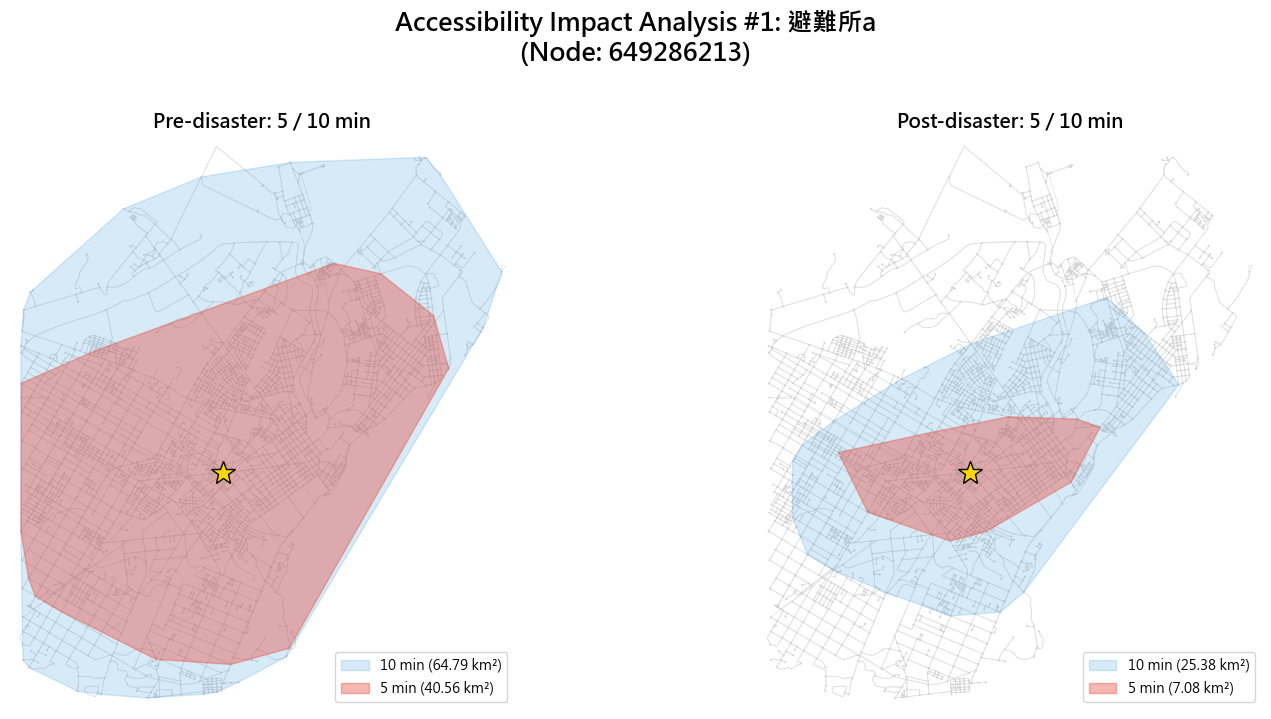

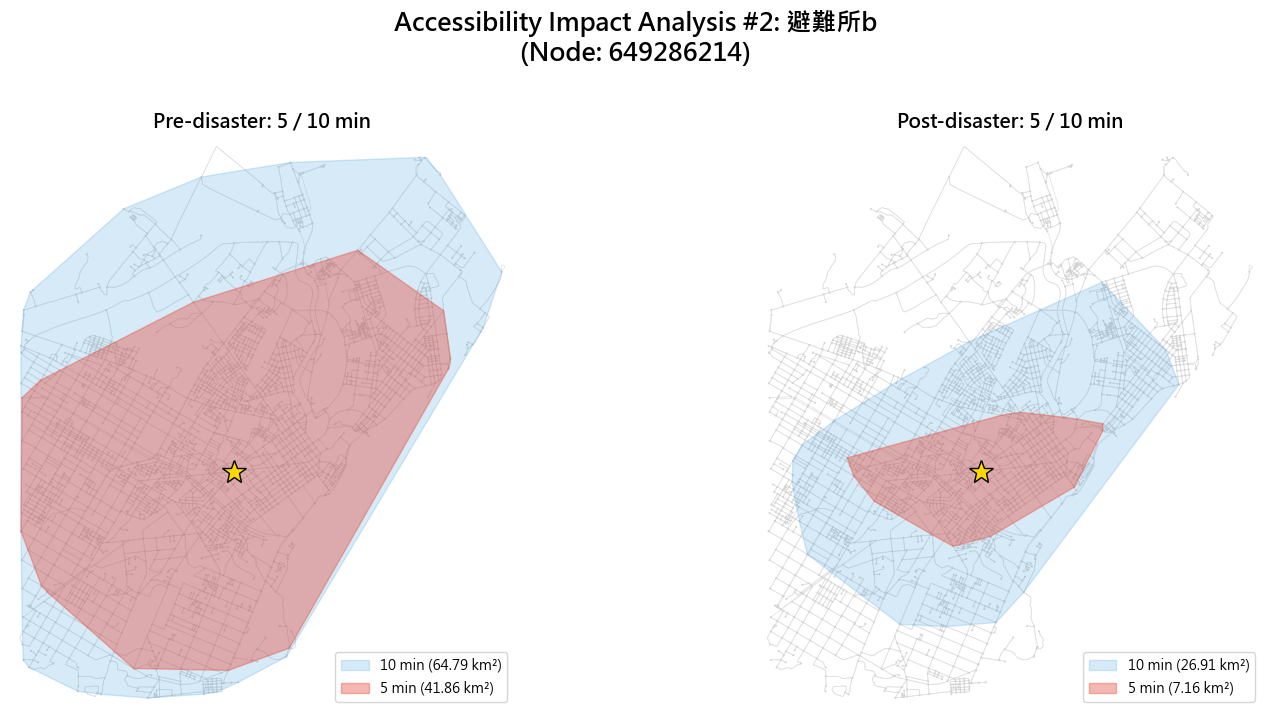

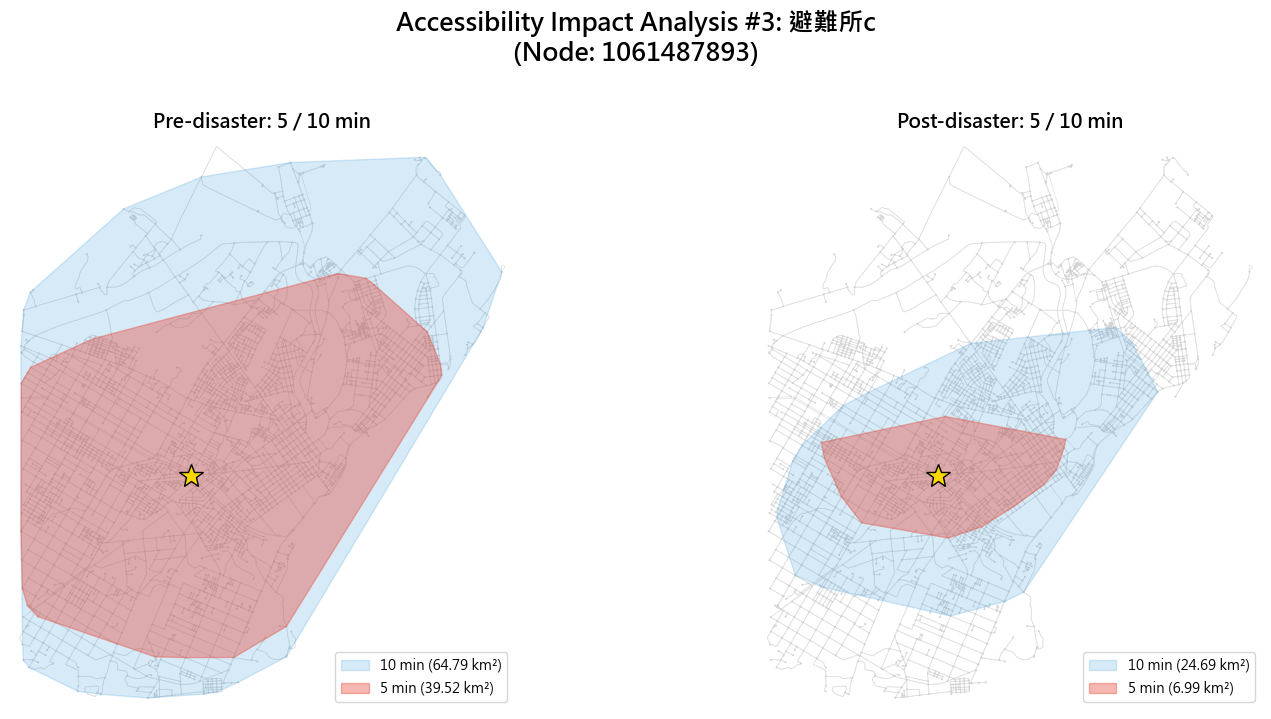

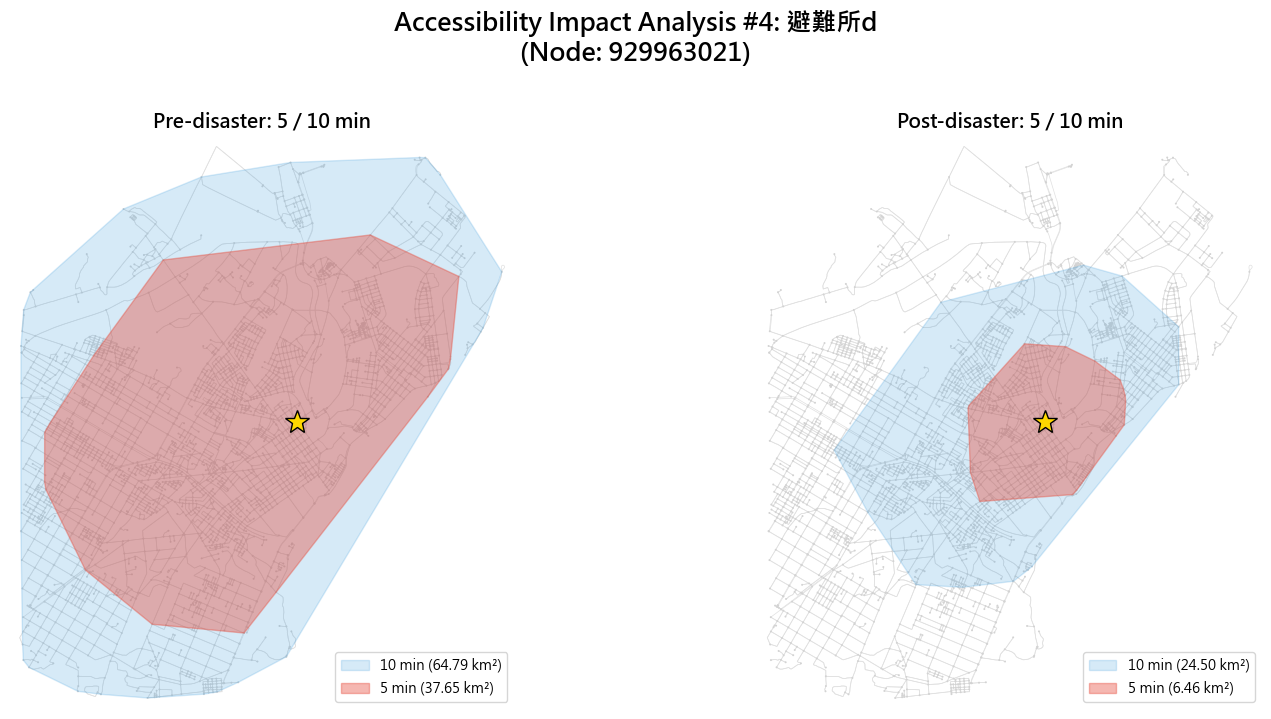

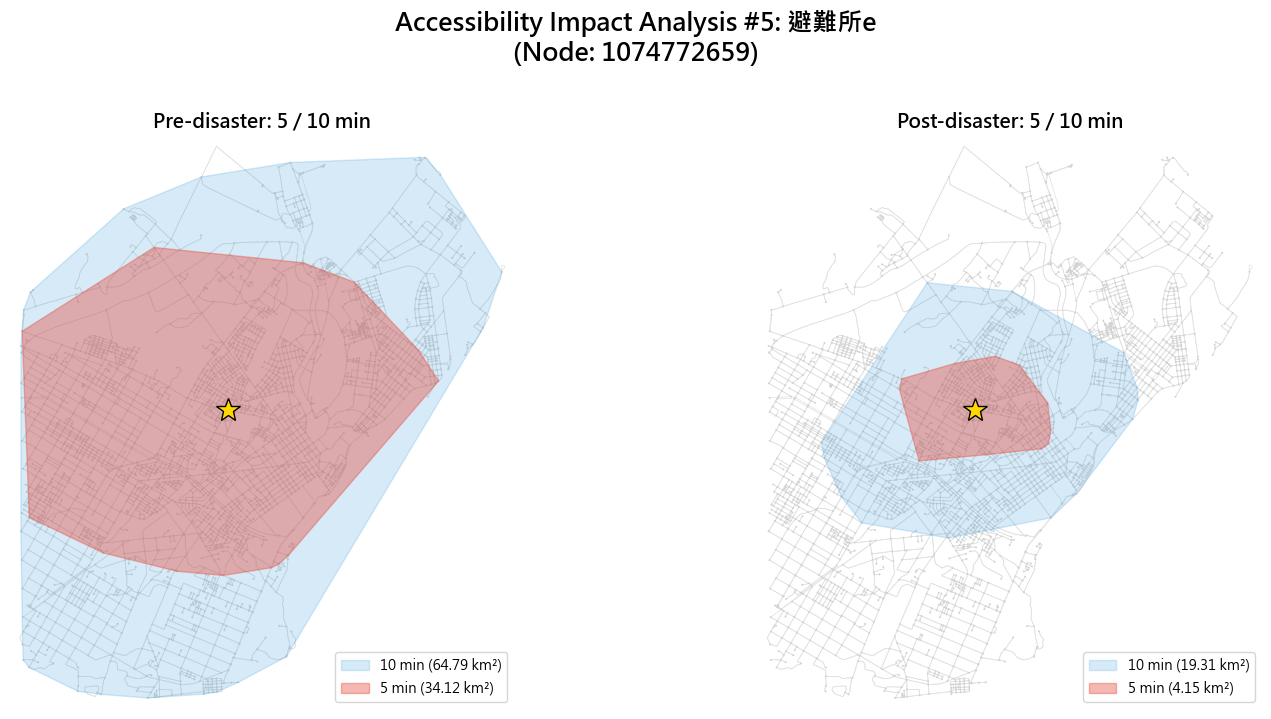

✅ 已成功產製 5 個避難所的 5分鐘/10 分鐘分析圖表。


In [22]:
# [S13] 一次產生前 5 個避難所的等時圈對照圖 (固定 5/10 分鐘)

# 1. 直接定義固定門檻 (秒)
T_SHORT = 300  # 5 分鐘
T_LONG = 600   # 10 分鐘

# 確保只處理前 5 個
num_to_plot = min(5, len(facility_node_ids))

for i in range(num_to_plot):
    facility_id = facility_node_ids[i]
    facility_name = facility_names[i]
    
    # 建立畫布 (1 列 2 欄)
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # 配置災前與災後的參數
    # 我們統一使用 T_SHORT (5min) 與 T_LONG (10min) 作為比較基準
    configs = [
        (axes[0], 'travel_time_normal', f'Pre-disaster: 5 / 10 min'),
        (axes[1], 'travel_time_adj',    f'Post-disaster: 5 / 10 min'),
    ]

    for ax, weight_attr, title in configs:
        # 畫底圖路網
        ox.plot_graph(G_proj, ax=ax, node_size=2, node_color='lightgray',
                      edge_color='#e0e0e0', edge_linewidth=0.5, show=False)
        
        # 2. 計算等時圈 (使用固定的 T_SHORT 與 T_LONG)
        reachable_short, _ = compute_isochrone(G_dyn, facility_id, weight_attr, T_SHORT)
        reachable_long,  _ = compute_isochrone(G_dyn, facility_id, weight_attr, T_LONG)
        
        # 轉多邊形
        poly_long,  area_long  = nodes_to_polygon(G_dyn, reachable_long)
        poly_short, area_short = nodes_to_polygon(G_dyn, reachable_short)
        
        # 填色與標籤更新
        if poly_long:
            x, y = poly_long.exterior.xy
            ax.fill(x, y, alpha=0.2, color='#3498db', label=f'10 min ({area_long/1e6:.2f} km²)')
        if poly_short:
            x, y = poly_short.exterior.xy
            ax.fill(x, y, alpha=0.4, color='#e74c3c', label=f'5 min ({area_short/1e6:.2f} km²)')
        
        # 標示起點
        fx = G_dyn.nodes[facility_id]['x']
        fy = G_dyn.nodes[facility_id]['y']
        ax.plot(fx, fy, marker='*', markersize=18, color='gold',
                markeredgecolor='black', markeredgewidth=1, zorder=10)
        
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.legend(loc='lower right', frameon=True, facecolor='white')

    # 設定整張圖的標題
    plt.suptitle(f'Accessibility Impact Analysis #{i+1}: {facility_name}\n(Node: {facility_id})', 
                  fontsize=18, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

print(f"✅ 已成功產製 {num_to_plot} 個避難所的 5分鐘/10 分鐘分析圖表。")

## 初始化 AI 決策顧問介面 (AI Tool Invocation Preparation)
建立與大型語言模型（LLM）的通訊橋樑，準備將 ARIA 系統產出的量化分析結果（如瓶頸節點與縮減率表）轉化為具備行動建議價值的「防災策略簡報」。

**執行邏輯與技術重點**：
- **開發套件整合**：採用最新版的 Google GenAI SDK，作為系統與 Gemini 模型之間的介面。這使得 ARIA 4.0 具備了將「冷冰冰的數據」解讀為「專業決策建議」的能力。
- **金鑰安全管理 (Security Best Practice)**：利用 `os.getenv` 函式從系統環境變數中讀取 API Key，而非將機敏金鑰直接寫死（Hard-code）在程式碼中。這符合專業軟體開發安全規範，防止金鑰外洩風險。
- **客戶端實例化**：透過 `genai.Client` 初始化連線物件。此物件將作為後續發送「Bonus Prompt」的核心通道，實現技術數據與人工智慧推理之間的無縫對接。
- **決策支援準備**：此步驟為系統的「智庫層」，旨在協助應變中心指揮官在極短時間內理解複雜的路網坍塌趨勢，並給出科學化的搶修優先順序建議。

In [23]:
# [S16] Prepare AI Tool Invocation (ChatGPT / Gemini / Claude / Other LLM)

# TODO: Install packages
# pip install google-generativeai

import os
from google import genai

api_key = os.getenv('GOOGLE_API_KEY')
# 1. 初始化 Client，使用新的 API Key，並考慮使用環境變數
client = genai.Client(api_key=api_key)

print("Prepare AI tool invocation (Use your preferred LLM)")
# print(api_key)

Prepare AI tool invocation (Use your preferred LLM)


## 產出 AI 防災決策建議 (Generating AI Disaster Response Briefing)
將複雜的量化分析結果整合為結構化指令，利用大型語言模型（LLM）模擬應變中心決策顧問，將數據分析轉化為具備行動價值的戰略報告。

**執行邏輯與技術重點**：
- **數據摘要與自動化提取 (Data Synthesis)**：系統自動從 `df_result` 與 `accessibility_table` 中提取「瓶頸節點」、「風險等級」以及「服務縮減率」等關鍵量化指標。透過邏輯判斷識別出縮減率大於 70% 的設施為「極端孤立設施」，實現從大數據中精煉關鍵情報。
- **提示詞工程 (Prompt Engineering)**：建構高度脈絡化的系統提示詞（Prompt），賦予 AI「花蓮縣災害應變中心決策顧問」的專業人格。指令中明確要求針對「優先搶通路段」、「替代救援方案」及「資源配置」三大維度進行推理分析。
- **模型調用與推理 (LLM Reasoning)**：採用 Google Gemini 等尖端模型處理多維度的空間分析結果。模型能理解介數中心性與地形風險的加乘關係，提供不僅是數據複述，更是基於專業防災邏輯的綜合研判。
- **決策轉換價值**：此環節完成了 ARIA 4.0 系統從「空間資訊系統 (GIS)」到「決策支援系統 (DSS)」的最終轉換。它能協助應變中心指揮官在資訊爆炸的災害現場，迅速獲取文字化的戰略重點，縮短從資料感知到採取行動的反應時間。

In [25]:
# 準備要餵給 AI 的文字數據
# 假設你之前的 DataFrame 叫做 df_result 和 accessibility_table
top5_info = df_result.sort_values('centrality', ascending=False).head(5)[['node_id', 'risk_level', 'centrality']].to_string()
access_info = accessibility_table.to_string()

# 找出縮減率大於 70% 的設施視為「極端孤立」
isolated_shelters = accessibility_table[accessibility_table['Short Shrink %'].str.rstrip('%').astype(float) > 70]['Shelter Name'].tolist()

prompt = f"""
你現在是「花蓮縣災害應變中心」的交通與應變決策顧問。
目前花蓮正受「鳳凰颱風」強降雨影響，ARIA 4.0 系統已產出最新的動態可及性分析結果。

【分析數據彙整】
1. 前五大路網瓶頸節點 (Top 5 Bottleneck Nodes):
{top5_info}

2. 避難所可及性衝擊表 (Accessibility Impact Table):
{access_info}

3. 受災嚴重/孤立設施 (Isolated Facilities):
{isolated_shelters}

請根據以上數據，以專業、果斷的防災報告格式，提供以下決策建議：

一、 優先搶通路段 (Priority Road Clearing):
請識別出哪些「瓶頸節點」最需要工程車進駐？請結合其「地形風險等級」說明理由。例如：若高中心性節點位於「極高風險區」，應優先預置機具。

二、 孤立區域的替代方案 (Alternative Rescue):
針對縮減率極高或已孤立的避難所，若陸路完全中斷，請評估是否需要啟動空投物資、空中接駁或規劃水路救援（若靠近海岸）。

三、 資源配置與撤離建議 (Resource Allocation):
根據 5min 與 10min 的等時圈縮減狀況，建議哪些區域的民眾應在雨量達到門檻前「提早撤離」？哪些設施應增派醫療人員進駐以因應可能的長期受困？

請使用繁體中文，語氣需正式且具備行動指導價值。
"""

print("--- 產出的 Bonus Prompt 如下 ---")
print(prompt)

# TODO: invokeyoupreferreduse  AI tool
# rangeexample: openai / google.generativeai / anthropic Both can
# response = model.generate_content(prompt)
# print("\n🤖 AI Strategy Report:")
# print(response.text)

# 使用新版 SDK 的請求方式
response = client.models.generate_content(
    model='gemini-3-flash-preview', 
    contents=prompt
)

print(response.text)

--- 產出的 Bonus Prompt 如下 ---

你現在是「花蓮縣災害應變中心」的交通與應變決策顧問。
目前花蓮正受「鳳凰颱風」強降雨影響，ARIA 4.0 系統已產出最新的動態可及性分析結果。

【分析數據彙整】
1. 前五大路網瓶頸節點 (Top 5 Bottleneck Nodes):
      node_id risk_level  centrality
0   649286213        高風險    0.140247
1   649286214        中風險    0.139444
2  1061487893        高風險    0.125307
3   929963021        高風險    0.123480
4  1074772659        低風險    0.115733

2. 避難所可及性衝擊表 (Accessibility Impact Table):
  Shelter Name Pre-5min (km²) Post-5min (km²) Short Shrink % Pre-10min (km²) Post-10min (km²) Long Shrink %
0         避難所a          40.56            7.08          82.5%           64.79            25.38         60.8%
1         避難所b          41.86            7.16          82.9%           64.79            26.91         58.5%
2         避難所c          39.52            6.99          82.3%           64.79            24.69         61.9%
3         避難所d          37.65            6.46          82.9%           64.79            24.50         62.2%
4         避難所e          34.12            4.

In [26]:
print(response.text)

**【鳳凰颱風強降雨受災路網與避難可及性分析決策建議書】**

**致：花蓮縣災害應變中心指揮官**
**報告人：交通與應變決策顧問**
**日期：202X年X月X日**
**案由：針對 ARIA 4.0 系統產出之動態路網瓶頸與避難所孤立風險，提出具體應變與部署建議。**

---

### 一、 優先搶通路段與機具預置建議 (Priority Road Clearing)

根據 ARIA 4.0 節點分析，本中心應立即針對以下關鍵節點進行兵力與工程機具預置，以防路網發生系統性崩解：

1.  **首要搶通核心 (Node 649286213)：**
    *   **風險評估：** 該節點具備最高中心性（0.140），且標記為「高風險」。此處為路網之樞紐，一旦中斷，將引發大規模連鎖反應。
    *   **決策建議：** **立即指派工務段至少 2 組重型機具（怪手、鏟裝車）於鄰近安全處待命。** 若該處位於蘇花公路或中橫關鍵轉折點，應派駐現場監測人員，一旦發生土石坍方，採「隨坍隨清」原則，維持單線通車。
2.  **關鍵聯外節點 (Node 1061487893 & 929963021)：**
    *   **風險評估：** 此兩處節點亦為「高風險」且中心性高（>0.12）。其位置通常連結主幹道與次要生活圈。
    *   **決策建議：** 此區域極易形成交通中斷點。應優先確保該路段排水通暢，並於雨量達 200mm/24h 門檻前，預先封閉高風險車道，保留緊急救援車道。
3.  **預備觀測節點 (Node 649286214)：**
    *   **風險評估：** 雖為「中風險」，但其中心性極高（0.139）。
    *   **決策建議：** 作為上述高風險節點的潛在替代路徑，應確保此路段不被違規停車或雜物阻塞，作為一級節點失效時的第二道防線。

---

### 二、 孤立區域之多元救援方案 (Alternative Rescue)

數據顯示「避難所 a 至 e」皆已列入孤立設施清單，路網服務功能大幅衰減。針對陸路完全中斷之預案如下：

1.  **啟動「避難所 e」空中接駁預案：**
    *   **分析：** 避難所 e 的 5 分鐘服務範圍縮減率達 **87.8%**，且 10 分鐘縮減率高達 **70.2%**，為所有設